In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
import plotly.express as px

In [3]:
medical_df = pd.read_csv("C:/dev/sklearn_freeCodeAcademy/full_course_Aakash_N_S/insurance.csv", encoding="utf-8-sig", low_memory=False)

In [4]:
non_smoker_df = medical_df[medical_df.smoker == "no"]

In [5]:
def rmse(targets, predictions):
    return np.sqrt(np.mean(np.square(targets - predictions)))

In [6]:
inputs, targets = non_smoker_df[["age", "bmi", "children"]], non_smoker_df["charges"]
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print("loss: ", loss)

loss:  4608.470405038246


inputs.shape:  (1338, 1)
targets.shape:  (1338,)


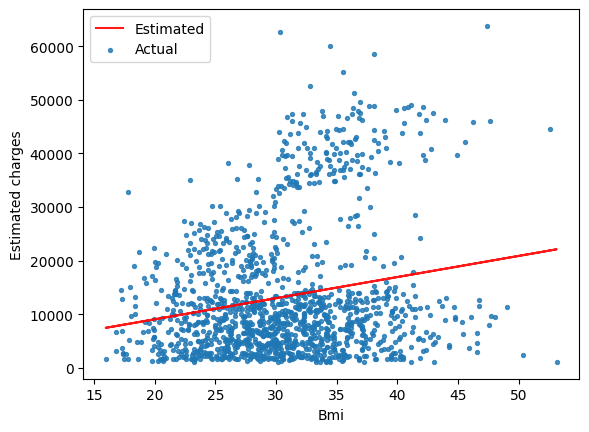

In [7]:
#traning using all features
inputs_all = medical_df[["bmi"]]
targets_all = medical_df.charges
print("inputs.shape: ", inputs_all.shape)
print("targets.shape: ", targets_all.shape)
model_all = LinearRegression()
model_all.fit(inputs_all, targets_all)
predictions_all = model_all.predict(inputs_all)

def rmse(targets_all, predictions_all):
    return np.sqrt(np.mean(np.square(targets_all - predictions_all)))
rmse(targets_all, predictions_all)
def try_params(w, b):
    bmi = medical_df.bmi
    target = medical_df.charges
    plt.plot(bmi, predictions_all, "r", alpha=0.9)
    plt.scatter(bmi, targets_all, s=8, alpha=0.8)
    plt.xlabel("Bmi")
    plt.ylabel("Estimated charges")
    plt.legend(["Estimated", "Actual"])
try_params(model_all.coef_,model_all.intercept_)

In [8]:
px.scatter(medical_df, x="age", y="charges", color="smoker")

Categorical Features

<Axes: xlabel='smoker', ylabel='charges'>

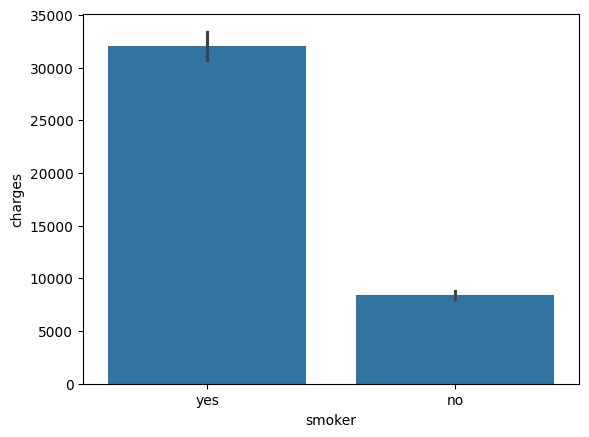

In [9]:
import seaborn as sns
sns.barplot(data=medical_df, x="smoker", y="charges")

In [10]:
smoker_codes = {"no":0, "yes":1}
medical_df["smoker_codes"] = medical_df.smoker.map(smoker_codes)

In [11]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_codes
0,19,female,27.900,0,yes,southwest,16884.92400,1
1,18,male,33.770,1,no,southeast,1725.55230,0
2,28,male,33.000,3,no,southeast,4449.46200,0
3,33,male,22.705,0,no,northwest,21984.47061,0
4,32,male,28.880,0,no,northwest,3866.85520,0
...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0
1334,18,female,31.920,0,no,northeast,2205.98080,0
1335,18,female,36.850,0,no,southeast,1629.83350,0
1336,21,female,25.800,0,no,southwest,2007.94500,0


In [12]:
medical_df.charges.corr(medical_df.smoker_codes)

np.float64(0.7872514304984778)

In [13]:
inputs,targets = medical_df[["age", "bmi", "children", "smoker_codes"]], medical_df["charges"]
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print("loss: ",loss)

loss:  6056.439217188081


<Axes: xlabel='sex', ylabel='charges'>

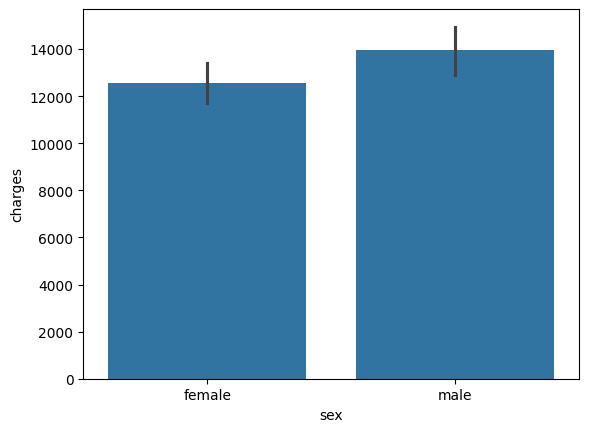

In [14]:
sns.barplot(data=medical_df, x="sex", y="charges")


In [15]:
sex_codes = {"female": 0, "male": 1}

In [16]:
medical_df["sex_codes"] = medical_df.sex.map(sex_codes)

In [17]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_codes,sex_codes
0,19,female,27.900,0,yes,southwest,16884.92400,1,0
1,18,male,33.770,1,no,southeast,1725.55230,0,1
2,28,male,33.000,3,no,southeast,4449.46200,0,1
3,33,male,22.705,0,no,northwest,21984.47061,0,1
4,32,male,28.880,0,no,northwest,3866.85520,0,1
...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1
1334,18,female,31.920,0,no,northeast,2205.98080,0,0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0


In [18]:
medical_df.charges.corr(medical_df.sex_codes)

np.float64(0.05729206220202533)

In [19]:
inputs,targets = medical_df[["age", "bmi", "children", "smoker_codes", "sex_codes"]], medical_df["charges"]
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print("loss: ",loss)

loss:  6056.100708754546


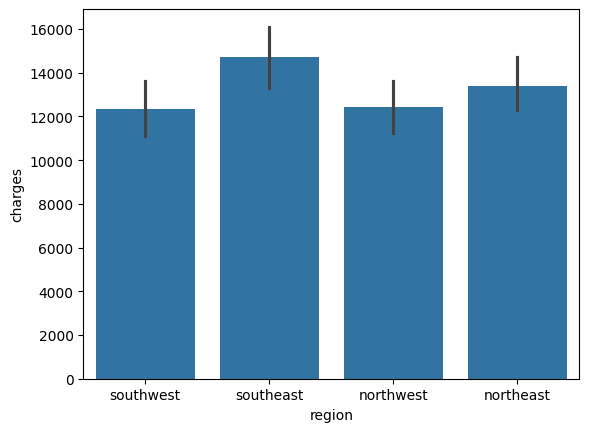

In [20]:
sns.barplot(data=medical_df, x="region", y="charges");

In [21]:
from sklearn import preprocessing
enc = preprocessing.OneHotEncoder()
enc.fit(medical_df[["region"]])
enc.categories_

[array(['northeast', 'northwest', 'southeast', 'southwest'], dtype=object)]

In [22]:
enc.transform([["northeast"],
                ["northwest"]]).toarray()

c:\dev\venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(


array([[1., 0., 0., 0.],
       [0., 1., 0., 0.]])

In [23]:
medical_df[["region"]]

,region
0,southwest
1,southeast
2,southeast
3,northwest
4,northwest
...,...
1333,northwest
1334,northeast
1335,southeast
1336,southwest


In [24]:
one_hot = enc.transform(medical_df[["region"]]).toarray()
one_hot

array([[0., 0., 0., 1.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 0., 1.],
       [0., 1., 0., 0.]], shape=(1338, 4))

In [25]:
medical_df[["northeast", "northwest", "southeast", "southwest"]] = one_hot

In [26]:
medical_df

,age,sex,bmi,children,smoker,region,charges,smoker_codes,sex_codes,northeast,northwest,southeast,southwest
0,19,female,27.900,0,yes,southwest,16884.92400,1,0,0.0,0.0,0.0,1.0
1,18,male,33.770,1,no,southeast,1725.55230,0,1,0.0,0.0,1.0,0.0
2,28,male,33.000,3,no,southeast,4449.46200,0,1,0.0,0.0,1.0,0.0
3,33,male,22.705,0,no,northwest,21984.47061,0,1,0.0,1.0,0.0,0.0
4,32,male,28.880,0,no,northwest,3866.85520,0,1,0.0,1.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1333,50,male,30.970,3,no,northwest,10600.54830,0,1,0.0,1.0,0.0,0.0
1334,18,female,31.920,0,no,northeast,2205.98080,0,0,1.0,0.0,0.0,0.0
1335,18,female,36.850,0,no,southeast,1629.83350,0,0,0.0,0.0,1.0,0.0
1336,21,female,25.800,0,no,southwest,2007.94500,0,0,0.0,0.0,0.0,1.0


In [40]:
inputs,targets = medical_df[["age", "bmi", "children", "smoker_codes", "northeast", "northwest", "southeast", "southwest"]], medical_df["charges"]
model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)
loss = rmse(targets, predictions)
print("loss: ",loss)

loss:  6042.033215394104


Model improvements, continuation from 5th_tutorial

In [41]:
input_cols = ["age", "bmi", "children", "smoker_codes", "sex_codes", "northeast"]
inputs, targets = medical_df[input_cols], medical_df["charges"]

model = LinearRegression().fit(inputs, targets)
predictions = model.predict(inputs)

loss = rmse(targets, predictions)
print("loss: ", loss)

loss:  6047.1830469152255


In [42]:
model.coef_

array([  257.28820648,   329.99475291,   480.44992836, 23820.40732565,
        -131.67213891,   774.65622475])

In [43]:
model.intercept_

np.float64(-12460.976838870483)

In [44]:
medical_df[input_cols].loc[10]

age             25.00
bmi             26.22
children         0.00
smoker_codes     0.00
sex_codes        1.00
northeast        1.00
Name: 10, dtype: float64

In [37]:
weights_df  = pd.DataFrame({
    "feature": np.append(input_cols, 1),
    "weight": np.append(model.coef_, model.intercept_)
})
weights_df

,feature,weight
0,age,257.288206
1,bmi,329.994753
2,children,480.449928
3,smoker_codes,23820.407326
4,sex_codes,-131.672139
5,northeast,774.656225
6,1,-12460.976839
